In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler
# geographical tools
# pandas dataframe-like geodataframes for geographical data
import geopandas as gpd
# used for obtaining a basemap of Canada
import contextily as ctx
# shapely is used to create and manipulate geometric shapes (like points, lines, polygons).
from shapely.geometry import Point

## Download the Canada map for reference

In [55]:
import requests
import zipfile
import os
import io
# url of the zip file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'
# directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok = True)
# step 1: download the zip file
response = requests.get(zip_file_url)
response.raise_for_status()
# step 2: open the zip file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # step 3: iterate over the files in the zip
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):
            # step 4: extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f'Download and extracted: {file_name}')

Download and extracted: Canada.tif


In [56]:
# write a function that plots clustered locations and overalys them on a basemap
def plot_clustered_locations(df, title = 'Museums Clustered by Proximity'):
    '''
    plot clustered locations and overlays on a basemap
    Parameters:
    - df: Dataframe containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    '''
    # load the coordinates into a geo dataframes
    gdf = gpd.GeoDataFrame(df, geometry = gpd.points_from_xy(df['Longitude'], df['Latitude']), crs = 'EPSG:4326')
    # reproject to web mercator to align with basemap
    gdf = gdf.to_crs(epsg = 3857)
    # create the plot
    fig, ax = plt.subplots(figsize = (15, 10))
    # separate non-noise, or clustered points from noise, or unclustered points
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]
    # plot noise points
    noise.plot(ax = ax, color = 'k', markersize = 30, ec = 'r', alpha = 1, label = 'Noise')
    # plot non-noise points
    non_noise.plot(ax = ax, column = 'Cluster', cmap = 'tab10', markersize = 30, ec = 'k', legend = False, alpha = 0.6)
    # add basemap of Canada
    ctx.add_basemap(ax, source = './Canada.tif', zoom = 4)
    # format plot
    plt.title(title, )
    plt.xlabel('Longitude', )
    plt.ylabel('Latitude', )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    # show the plot
    plt.show()

In [57]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
df = pd.read_csv(url, encoding = 'ISO-8859-1')

In [58]:
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Index                  7972 non-null   int64 
 1   Facility_Name          7972 non-null   object
 2   Source_Facility_Type   7972 non-null   object
 3   ODCAF_Facility_Type    7972 non-null   object
 4   Provider               7972 non-null   object
 5   Unit                   7972 non-null   object
 6   Street_No              7972 non-null   object
 7   Street_Name            7972 non-null   object
 8   Postal_Code            7972 non-null   object
 9   City                   7972 non-null   object
 10  Prov_Terr              7972 non-null   object
 11  Source_Format_Address  7972 non-null   object
 12  CSD_Name               7972 non-null   object
 13  CSDUID                 7972 non-null   object
 14  PRUID                  7972 non-null   object
 15  Latitude             

In [60]:
df.ODCAF_Facility_Type.value_counts()

ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64

In [61]:
df = df[df['ODCAF_Facility_Type'] == 'museum']
df

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
8,10,12 Service Battalion Museum,military museum or fort,museum,canadian museums association,..,5500,no 4 rd,V6X 3L5,richmond,bc,5500 no. 4 rd the sherman armoury richmond bri...,Richmond,5915015,59,49.1763542,-123.112783
13,15,15th Field Artillery Regiment Museum And Archives,museum/gallery,museum,vancouver,..,2025,11th av w,V6J 2C7,vancouver,bc,2025 w 11th av vancouver bc v6j 2c7,Vancouver,5915022,59,49.261938,-123.151123
15,18,17 Wing Heritage Collection,aeronautics and space museum transportation mu...,museum,canadian museums association,..,..,..,R3J 3Y5,winnipeg,mb,air heritage park air force way winnipeg manit...,Winnipeg,4611040,46,49.88955855,-97.23574396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7940,9765,York Region District School Board Museum & Arc...,library and/or archives community/regional museum,museum,canadian museums association,..,21,renfrew dr,L3R 8H3,markham,on,21 renfrew dr markham ontario l3r 8h3 canada,Markham,3519036,35,43.857692,-79.3619396
7954,9779,Youthlink Calgary-The Calgary Police Interpret...,community/regional museum exhibition or cultur...,museum,canadian museums association,..,5111,47th street ne,T3J 3R2,calgary,ab,5111-47th street ne lc594 calgary alberta t3j ...,Calgary,4806016,48,..,..
7958,9783,Yukon Beringia Interpretive Centre,human history-archaelogy-anthropology or ethno...,museum,canadian museums association,..,1423,alaska hwy,Y1A 2C6,whitehorse,yt,kilometre 1423 (mile 886) alaska hwy po box 27...,Whitehorse,6001009,60,..,..
7968,9797,Craigdarroch Castle,museums and galleries,museum,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.42241956,-123.3435527


In [62]:
df = df[['Latitude', 'Longitude']]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1938 entries, 1 to 7969
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Latitude   1938 non-null   object
 1   Longitude  1938 non-null   object
dtypes: object(2)
memory usage: 45.4+ KB


In [63]:
df['Latitude'].value_counts()

Latitude
..             331
51.01423945      6
45.71061766      3
48.369878        3
60.72105795      2
              ... 
43.03389196      1
42.83279348      1
50.511706        1
43.89208166      1
42.31850631      1
Name: count, Length: 1584, dtype: int64

In [64]:
df['Longitude'].value_counts()

Longitude
..              331
-114.1162943      6
-63.2859451       3
-53.359843        3
-135.0516172      2
               ... 
-79.01975466      1
-79.93681622      1
-116.0288768      1
-79.26752268      1
-83.04242908      1
Name: count, Length: 1584, dtype: int64

In [65]:
df = df[df['Latitude'] != '..']
df[['Latitude', 'Longitude']] = x[['Latitude', 'Longitude']].astype('float')

## Build a DBSCAN model

In [66]:
# in this case we know how to scale the coordinates. Using standarization would be an error becuz we aren't using the full range
# of the lat/lng coordinates.
# since latitude has a range of +/- 90 degrees and longitude ranges from 0 to 360 degrees, the correct scaling is to double the longitude cooridinates
# or half the latitudes
corr_scaled = df.copy()
corr_scaled['Latitude'] = corr_scaled['Latitude'] * 2

## Apply DBSCAN with Euclidean distance to the scaled coordinates

In [67]:
dbscan = DBSCAN(eps = 1.0, min_samples = 3, metric = 'euclidean')

In [68]:
dbscan.fit(corr_scaled)

DBSCAN(eps=1.0, min_samples=3)

## Add cluster labels to the DataFrame

In [69]:
# assign the cluster labels
df['Cluster'] = dbscan.fit_predict(corr_scaled)
# display the size of each cluster
df['Cluster'].value_counts()

Cluster
 4     701
 2     192
 1     181
 7     134
 3      94
-1      79
 6      30
 10     27
 8      21
 11     15
 15     13
 20     11
 16     10
 19      9
 27      8
 12      7
 26      6
 5       6
 24      6
 28      6
 14      6
 18      6
 13      4
 9       4
 22      4
 0       3
 23      3
 21      3
 17      3
 25      3
 29      3
 31      3
 30      3
 32      3
Name: count, dtype: int64

## Plot the museums on a basemap of Canada, colored by cluster label

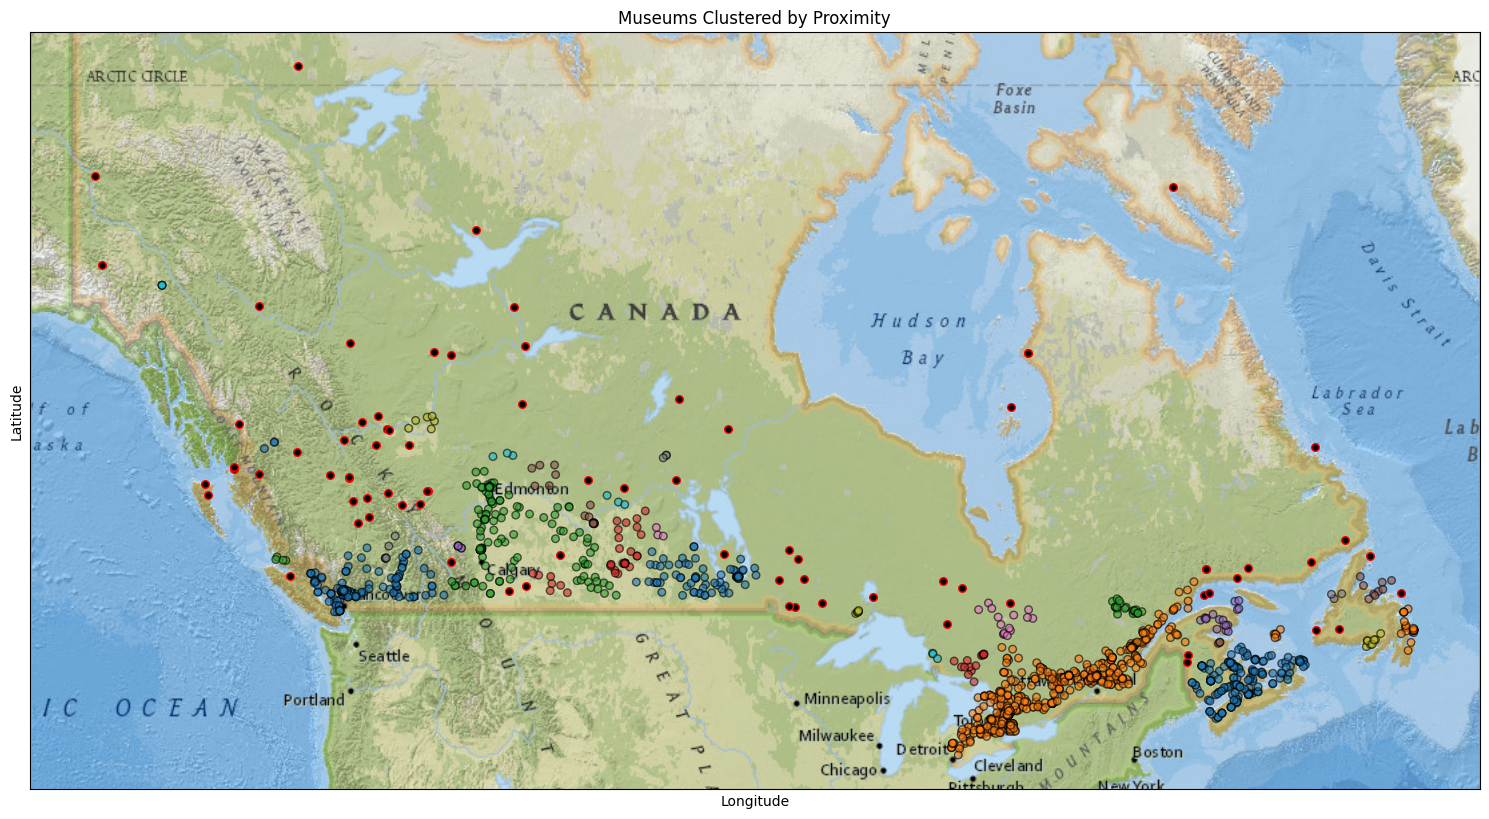

In [70]:
plot_clustered_locations(df, title = 'Museums Clustered by Proximity')

## Build an HDBSCAN Clustering Model

In [71]:
# initial an HDBSCAN model
hdb = hdbscan.HDBSCAN(min_samples = None, min_cluster_size = 3, metric = 'euclidean')

In [72]:
# assign labels
df['Cluster'] = hdb.fit_predict(corr_scaled)
# display the size of each cluster
df['Cluster'].value_counts()

C:\Users\Sammi Wang\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Sammi Wang\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Cluster
-1      454
 137     44
 97      39
 58      35
 93      33
       ... 
 133      3
 39       3
 69       3
 47       3
 132      3
Name: count, Length: 141, dtype: int64

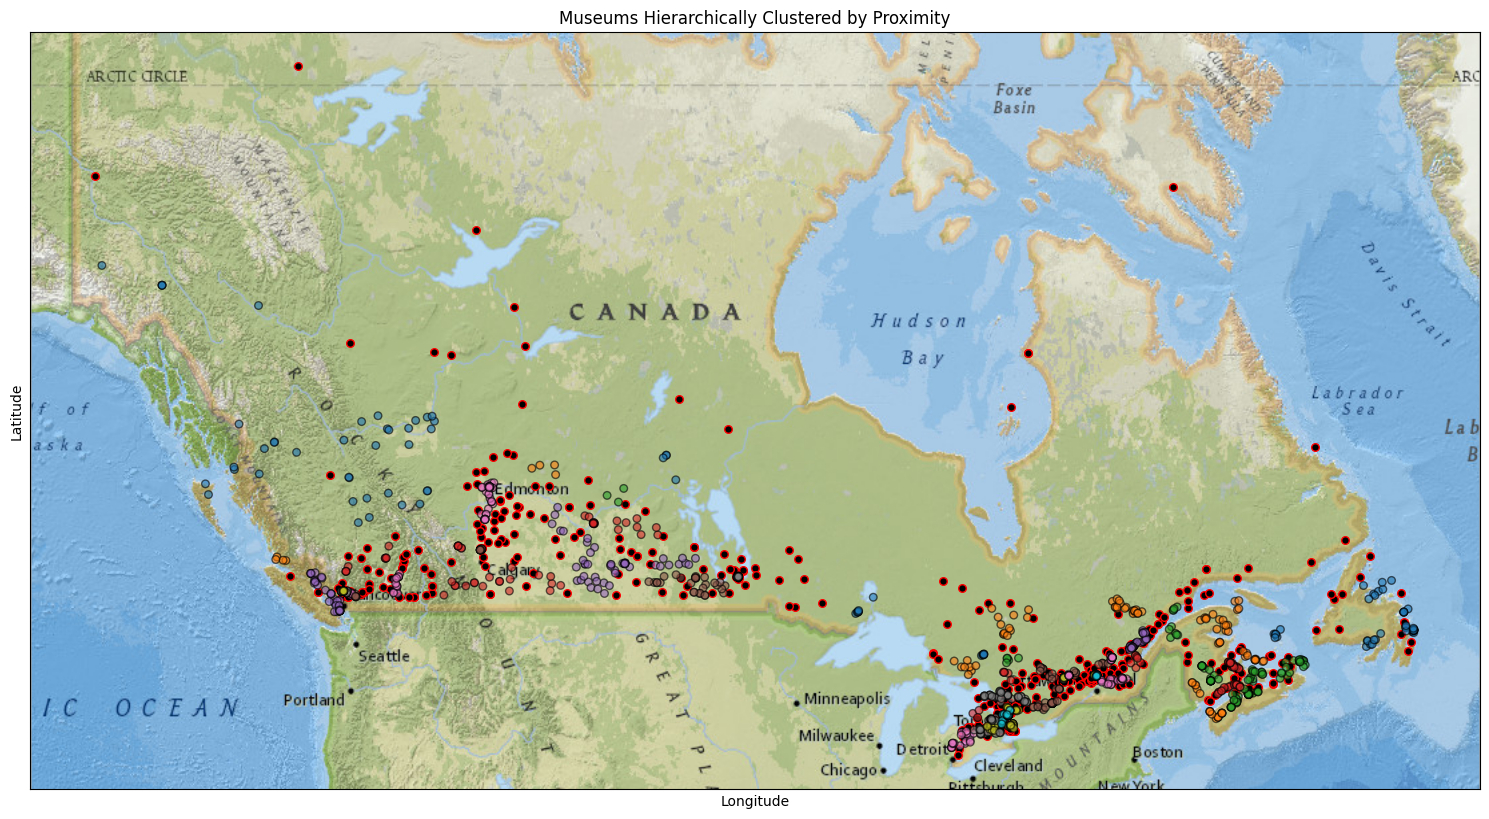

In [73]:
# plot the museum clusters
plot_clustered_locations(df, title = 'Museums Hierarchically Clustered by Proximity')